In [ ]:
!pip install xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel(r"/content/sample_data/smart_dam_dataset_updated.xlsx")

In [ ]:
# Remove unwanted columns (if any)
df = df.dropna()

# Convert timestamp if exists
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# Features and target
X = df[['rainfall', 'water_level', 'pressure']]
y = df['water_level']   # forecasting water level

In [ ]:
print("\nData Types:\n", df.dtypes)


Data Types:
 timestamp           datetime64[ns]
rainfall                   float64
inflow                     float64
outflow                    float64
water_level                float64
pressure                   float64
water_level_prev           float64
rain_avg_3h                float64
gate_status                  int64
risk                        object
dtype: object


In [ ]:
print("\nCleaned Data Preview:\n", df.head())


Cleaned Data Preview:
             timestamp  rainfall    inflow   outflow  water_level   pressure  \
0 2025-01-01 01:00:00  5.300915  5.543026  2.027209    49.893820  49.564600   
1 2025-01-01 02:00:00  0.000000  0.000000  0.911898    49.968251  47.241833   
2 2025-01-01 03:00:00  0.000000  0.000000  0.573384    49.877061  48.972287   
3 2025-01-01 04:00:00  9.014899  9.461149  2.810452    49.819722  46.166041   
4 2025-01-01 05:00:00  2.262156  1.814820  0.539932    50.011735  47.284456   

   water_level_prev  rain_avg_3h  gate_status     risk  
0         50.000000     5.300915            1     SAFE  
1         49.893820     1.766972            0     SAFE  
2         49.968251     1.766972            0     SAFE  
3         49.877061     3.004966            1  WARNING  
4         49.819722     3.759018            0     SAFE  


In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)

print("\nData Cleaning Completed Successfully!")


Data Cleaning Completed Successfully!


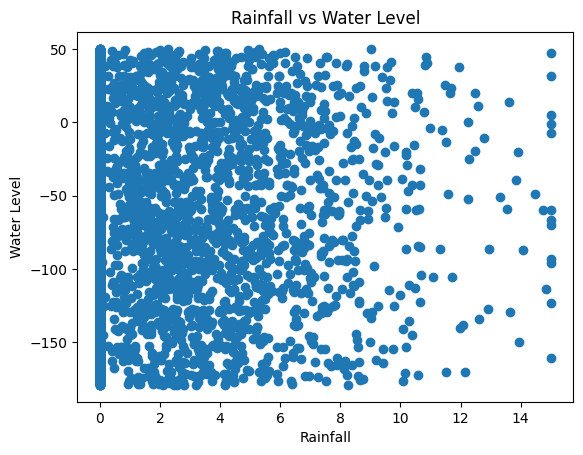

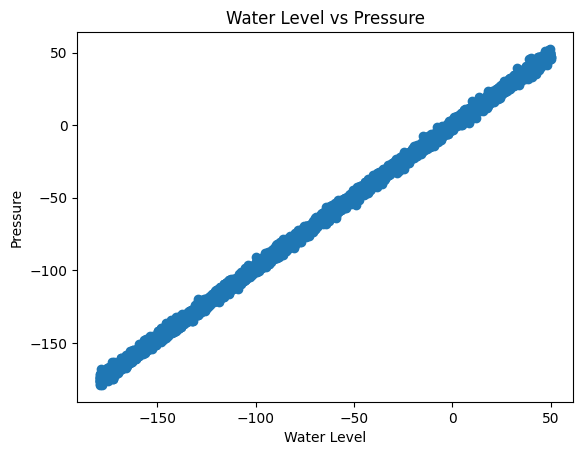

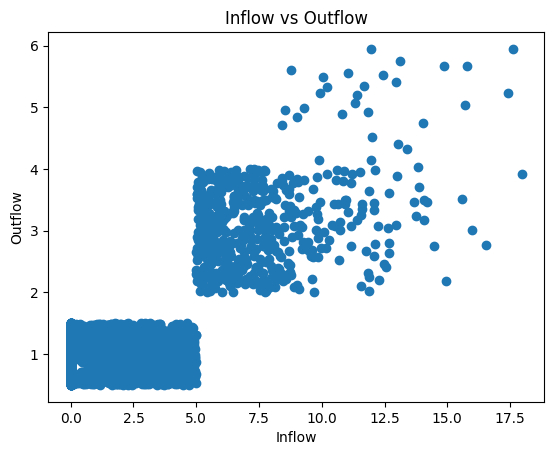

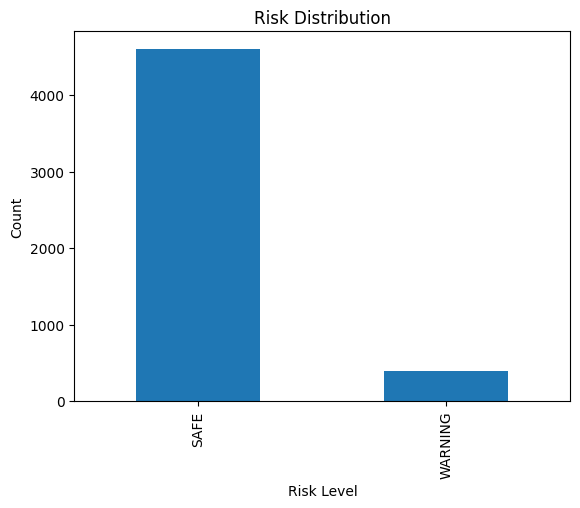

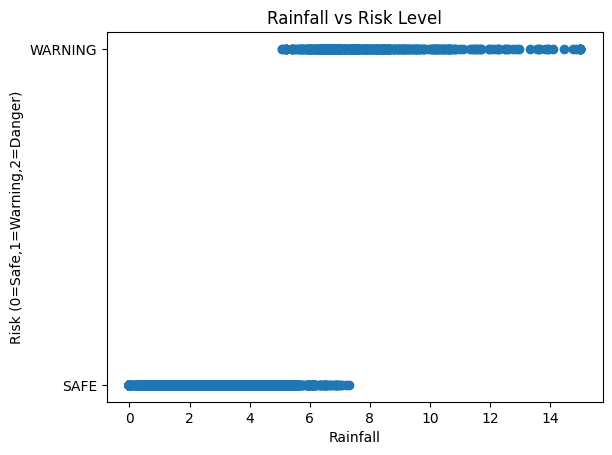

In [ ]:
plt.figure()
plt.scatter(df['rainfall'], df['water_level'])
plt.xlabel("Rainfall")
plt.ylabel("Water Level")
plt.title("Rainfall vs Water Level")
plt.show()

plt.figure()
plt.scatter(df['water_level'], df['pressure'])
plt.xlabel("Water Level")
plt.ylabel("Pressure")
plt.title("Water Level vs Pressure")
plt.show()

plt.figure()
plt.scatter(df['inflow'], df['outflow'])
plt.xlabel("Inflow")
plt.ylabel("Outflow")
plt.title("Inflow vs Outflow")
plt.show()


plt.figure()
df['risk'].value_counts().plot(kind='bar')
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.title("Risk Distribution")
plt.show()


plt.figure()
plt.scatter(df['rainfall'], df['risk'])
plt.xlabel("Rainfall")
plt.ylabel("Risk (0=Safe,1=Warning,2=Danger)")
plt.title("Rainfall vs Risk Level")
plt.show()

ML MODEL BUILDING

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

XGBoost RMSE: 0.3272546089675699


In [ ]:
lgb_model = LGBMRegressor()
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

print("LightGBM RMSE:", np.sqrt(mean_squared_error(y_test, lgb_pred)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 3999, number of used features: 3
[LightGBM] [Info] Start training from score -61.656359
LightGBM RMSE: 0.31629680192265525


In [ ]:
# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['rainfall', 'water_level', 'pressure']])

# Create sequences
X_lstm = []
y_lstm = []

for i in range(10, len(scaled_data)):
    X_lstm.append(scaled_data[i-10:i])
    y_lstm.append(scaled_data[i][1])  # waterlevel

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Split
split = int(0.8 * len(X_lstm))
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

# Model
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=False, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

# Train
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=16)

# Predict
lstm_pred = lstm_model.predict(X_test_lstm)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0083
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.9948e-06
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.6142e-06
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5.5749e-06
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5.5658e-06
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.8534e-06
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.6648e-06
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.1084e-06
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.6806e-06
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.3649e-06
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


LIGHTGBM IMPLEMENTATION

In [ ]:
# Align predictions
min_len = min(len(xgb_pred), len(lgb_pred), len(lstm_pred))

hybrid_pred = (
    xgb_pred[:min_len] +
    lgb_pred[:min_len] +
    lstm_pred[:min_len].flatten()
) / 3

y_true = y_test.values[:min_len]

print("Hybrid RMSE:", np.sqrt(mean_squared_error(y_true, hybrid_pred)))

Hybrid RMSE: 29.59359140332137


In [ ]:
def classify_risk(water, pressure):
    if water > 300 or pressure > 400:
        return "HIGH"
    elif water > 200:
        return "MEDIUM"
    else:
        return "LOW"

# Apply
df['risk'] = df.apply(lambda row: classify_risk(row['water_level'], row['pressure']), axis=1)

df[['water_level', 'pressure', 'risk']].head()

,water_level,pressure,risk
0,49.893820,49.564600,LOW
1,49.968251,47.241833,LOW
2,49.877061,48.972287,LOW
3,49.819722,46.166041,LOW
4,50.011735,47.284456,LOW


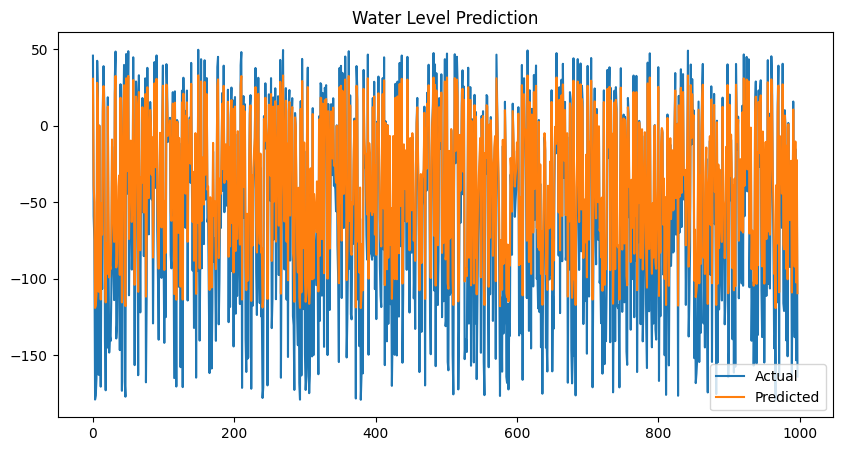

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_true, label="Actual")
plt.plot(hybrid_pred, label="Predicted")
plt.legend()
plt.title("Water Level Prediction")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# 🔹 Calculate RMSE for each model
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))

# For LSTM (make sure lengths match)
lstm_true = y_test_lstm[:len(lstm_pred)]
lstm_rmse = np.sqrt(mean_squared_error(lstm_true, lstm_pred))

# Hybrid RMSE (already aligned earlier)
hybrid_rmse = np.sqrt(mean_squared_error(y_true, hybrid_pred))

# 🔹 Store results in a table
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "LSTM", "Hybrid"],
    "RMSE": [xgb_rmse, lgb_rmse, lstm_rmse, hybrid_rmse]
})

# 🔹 Sort by best model
results = results.sort_values(by="RMSE")

# 🔹 Display
print(results)

      Model       RMSE
2      LSTM   0.014851
1  LightGBM   0.316297
0   XGBoost   0.327255
3    Hybrid  29.593591


In [ ]:
# Reconstruct full array to inverse scale
lstm_pred_full = np.zeros((len(lstm_pred), 3))
lstm_pred_full[:, 1] = lstm_pred.flatten()  # waterlevel column

lstm_pred_rescaled = scaler.inverse_transform(lstm_pred_full)[:, 1]

In [ ]:
min_len = min(len(xgb_pred), len(lgb_pred), len(lstm_pred_rescaled))

xgb_p = xgb_pred[:min_len]
lgb_p = lgb_pred[:min_len]
lstm_p = lstm_pred_rescaled[:min_len]
y_true = y_test.values[:min_len]

LSTM-(Time series)

In [ ]:
hybrid_pred = (xgb_p + lgb_p + lstm_p) / 3

In [ ]:
from sklearn.metrics import mean_squared_error

xgb_rmse = np.sqrt(mean_squared_error(y_true, xgb_p))
lgb_rmse = np.sqrt(mean_squared_error(y_true, lgb_p))
lstm_rmse = np.sqrt(mean_squared_error(y_true, lstm_p))
hybrid_rmse = np.sqrt(mean_squared_error(y_true, hybrid_pred))

import pandas as pd

results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "LSTM", "Hybrid"],
    "RMSE": [xgb_rmse, lgb_rmse, lstm_rmse, hybrid_rmse]
}).sort_values(by="RMSE")

print(results)

      Model        RMSE
1  LightGBM    0.316276
0   XGBoost    0.327356
3    Hybrid   38.038086
2      LSTM  114.092032


In [ ]:
hybrid_pred = (0.6 * xgb_p) + (0.4 * lgb_p)

In [ ]:
from sklearn.metrics import mean_squared_error

xgb_rmse = np.sqrt(mean_squared_error(y_true, xgb_p))
lgb_rmse = np.sqrt(mean_squared_error(y_true, lgb_p))
lstm_rmse = np.sqrt(mean_squared_error(y_true, lstm_p))
hybrid_rmse = np.sqrt(mean_squared_error(y_true, hybrid_pred))

import pandas as pd

results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "LSTM", "Hybrid"],
    "RMSE": [xgb_rmse, lgb_rmse, lstm_rmse, hybrid_rmse]
}).sort_values(by="RMSE")

print(results)

      Model        RMSE
3    Hybrid    0.237150
1  LightGBM    0.316276
0   XGBoost    0.327356
2      LSTM  114.092032
